In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
df = pd.read_csv("factory_production.csv")
df.head(10)

,Tanggal,Shift,Mesin,Jumlah_Produksi,Jumlah_Cacat,Downtime (menit),Suhu_Mesin,Kelembaban
0,2025-11-01,Pagi,A,376,6,9.9,80.3,55.3
1,2025-11-01,Pagi,B,351,4,54.4,82.1,35.4
2,2025-11-01,Pagi,C,395,8,2.0,72.8,55.2
3,2025-11-01,Pagi,D,466,6,20.3,70.4,54.6
4,2025-11-01,Siang,A,339,3,3.2,70.0,51.9
5,2025-11-01,Siang,B,224,2,11.6,79.4,49.9
6,2025-11-01,Siang,C,294,8,5.7,85.7,68.4
7,2025-11-01,Siang,D,353,10,4.6,80.6,46.7
8,2025-11-01,Malam,A,254,10,10.0,91.1,59.6
9,2025-11-01,Malam,B,231,6,1.8,79.4,63.9


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tanggal           1080 non-null   str    
 1   Shift             1080 non-null   str    
 2   Mesin             1080 non-null   str    
 3   Jumlah_Produksi   1080 non-null   int64  
 4   Jumlah_Cacat      1080 non-null   int64  
 5   Downtime (menit)  1059 non-null   float64
 6   Suhu_Mesin        1048 non-null   float64
 7   Kelembaban        1037 non-null   float64
dtypes: float64(3), int64(2), str(3)
memory usage: 67.6 KB


In [5]:
#statistik deskriptif
df.describe()

,Jumlah_Produksi,Jumlah_Cacat,Downtime (menit),Suhu_Mesin,Kelembaban
count,1080.000000,1080.000000,1059.000000,1048.000000,1037.000000
mean,349.600000,7.934259,15.110009,76.951718,49.857281
std,59.510571,4.416073,15.214485,8.218287,10.178976
min,142.000000,0.000000,0.000000,55.000000,25.000000
25%,311.000000,5.000000,4.300000,70.900000,42.900000
50%,349.000000,7.000000,10.800000,77.100000,49.900000
75%,390.250000,10.000000,20.200000,82.500000,56.800000
max,528.000000,42.000000,110.300000,104.900000,79.200000


In [ ]:

df.isnull().sum()

Tanggal              0
Shift                0
Mesin                0
Jumlah_Produksi      0
Jumlah_Cacat         0
Downtime (menit)    21
Suhu_Mesin          32
Kelembaban          43
dtype: int64

In [7]:
df["Downtime (menit)"] = df["Downtime (menit)"].fillna(df["Downtime (menit)"].mean())

df["Suhu_Mesin"] = df["Suhu_Mesin"].fillna(df["Suhu_Mesin"].mean())

df["Kelembaban"] = df["Kelembaban"].fillna(df["Kelembaban"].mean())

Berdasarkan hasil inspeksi, terdapat missing value pada kolom Downtime (menit), Suhu_Mesin, dan Kelembaban. Missing value ditangani menggunakan metode imputasi dengan nilai rata-rata (mean) karena ketiga kolom tersebut merupakan data numerik kontinu. Metode ini dipilih agar jumlah data tetap dipertahankan dan distribusi data tidak berubah secara signifikan.

In [14]:
df.isnull().sum()

Tanggal             0
Shift               0
Mesin               0
Jumlah_Produksi     0
Jumlah_Cacat        0
Downtime (menit)    0
Suhu_Mesin          0
Kelembaban          0
dtype: int64

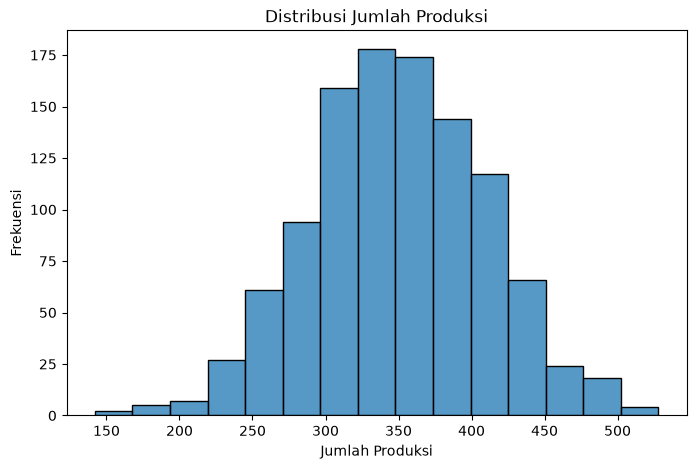

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["Jumlah_Produksi"], bins=15)

plt.title("Distribusi Jumlah Produksi")

plt.xlabel("Jumlah Produksi")

plt.ylabel("Frekuensi")

plt.show()

Histogram digunakan untuk melihat distribusi jumlah produksi pada dataset. Dari grafik dapat diketahui apakah sebagian besar data terkonsentrasi pada rentang tertentu atau memiliki penyebaran yang luas.

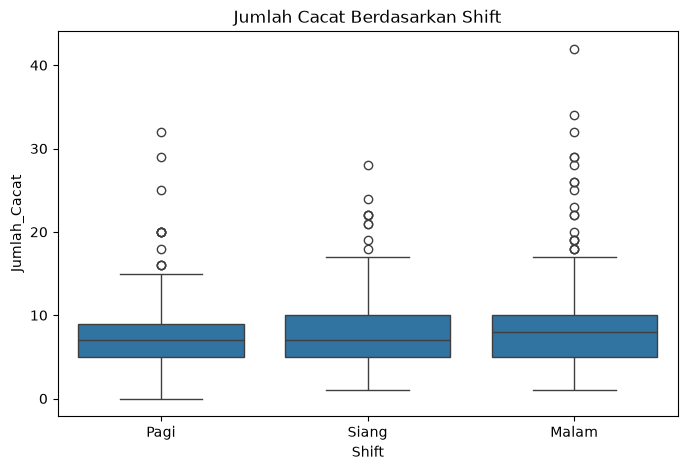

In [16]:
#visualisasi kedua 

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Shift",
    y="Jumlah_Cacat"
)

plt.title("Jumlah Cacat Berdasarkan Shift")

plt.show()

Boxplot digunakan untuk membandingkan distribusi jumlah produk cacat pada setiap shift kerja serta mendeteksi adanya outlier.

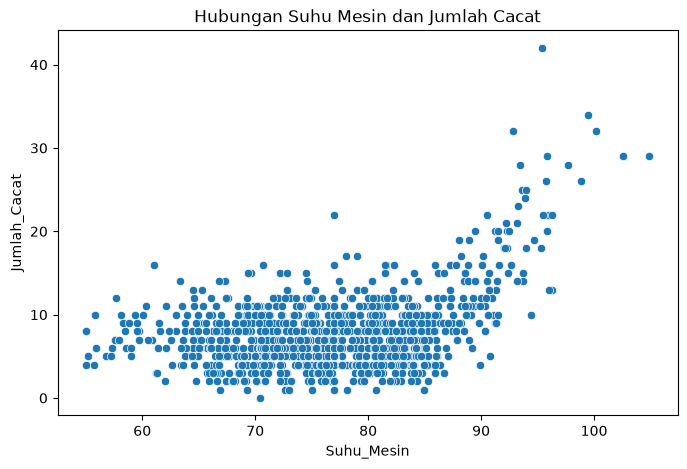

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Suhu_Mesin",
    y="Jumlah_Cacat"
)

plt.title("Hubungan Suhu Mesin dan Jumlah Cacat")

plt.show()

Scatter plot digunakan untuk melihat hubungan antara suhu mesin dan jumlah produk cacat. Penyebaran titik pada grafik dapat menunjukkan ada atau tidaknya kecenderungan hubungan antara kedua variabel tersebut.

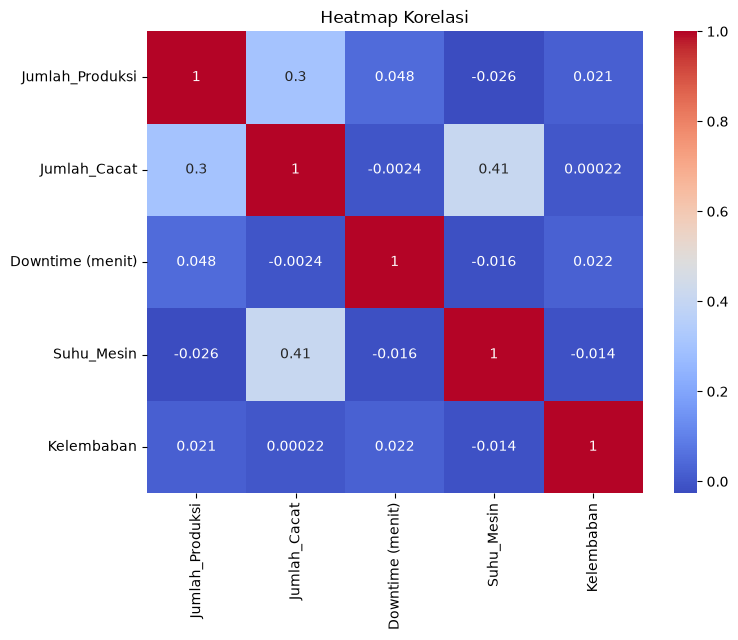

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Heatmap Korelasi")

plt.show()